# 02 — Exploratory Environmental Analysis

**Project:** Brisbane River Water Quality Analysis

## Purpose of this notebook

This notebook explores the cleaned dataset (`data/processed/water_quality_cleaned.csv`,
produced by Notebook 1) to identify meaningful environmental patterns and answer the
project's research questions.

## Research questions

- **RQ1** — What are the typical water-quality conditions?
- **RQ2** — Which water-quality parameters show the greatest variability?
- **RQ3** — How does water quality change over time?
- **RQ4** — Are there identifiable monthly or seasonal patterns?
- **RQ5** — What relationships exist between water-quality parameters?
- **RQ6** — Are there periods of unusual water-quality conditions?

## A note on interpretation

This is an exploratory, observational analysis. Wording throughout uses
*"associated with"*, *"correlated with"*, *"may indicate"* rather than causal language —
correlation here does not establish cause, and any pattern flagged as "unusual" or
"interesting" **warrants further investigation**, not a firm conclusion.


## 1. Import libraries and load cleaned dataset

In [1]:
import os
from pathlib import Path

REPO_DIR = "brisbane-river-water-quality-analysis"
REPO_URL = "https://github.com/davis-mironga/brisbane-river-water-quality-analysis.git"

def in_repo_notebooks_dir():
    return Path("../README.md").exists() and Path("../src").exists()

if not in_repo_notebooks_dir():
    if not Path(REPO_DIR).exists():
        print("Repo not found locally -- cloning...")
        os.system(f"git clone {REPO_URL}")
    os.chdir(f"{REPO_DIR}/notebooks")

print("Working directory:", os.getcwd())

Working directory: /workspaces/brisbane-river-water-quality-analysis/notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RAW_PATH = Path('../data/raw/brisbane_water_quality.csv')
PROCESSED_PATH = Path('../data/processed/water_quality_cleaned.csv')
DATA_URL = "https://github.com/davis-mironga/brisbane-river-water-quality-analysis/releases/download/v1.0-data/brisbane_water_quality.csv"

if not PROCESSED_PATH.exists():
    sys.path.insert(0, '../src')
    import cleaning
    print('Processed dataset not found -- regenerating from raw data using src/cleaning.py...')
    df_raw = cleaning.load_raw_data(RAW_PATH, download_url=DATA_URL)
    df = cleaning.rename_columns(df_raw)
    df = cleaning.convert_timestamp(df)
    df = cleaning.add_time_features(df)
    cleaning.validate_cleaned_dataset(df, original_row_count=len(df_raw))
    PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(PROCESSED_PATH, index=False)
    print(f'Regenerated and saved {len(df):,} rows to {PROCESSED_PATH}')

df = pd.read_csv(PROCESSED_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'])

SEASON_ORDER = ['Summer', 'Autumn', 'Winter', 'Spring']
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['season'] = pd.Categorical(df['season'], categories=SEASON_ORDER, ordered=True)
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=DOW_ORDER, ordered=True)

print(f'Loaded {len(df):,} rows, {df.shape[1]} columns')
print(f'Date range: {df["timestamp"].min()} to {df["timestamp"].max()}')
df.head()

Loaded 30,894 rows, 26 columns
Date range: 2023-08-04 23:00:00 to 2024-06-27 09:00:00


,timestamp,record_number,water_speed,water_direction,chlorophyll,chlorophyll_quality,temperature,temperature_quality,dissolved_oxygen,dissolved_oxygen_quality,dissolved_oxygen_pct_sat,dissolved_oxygen_pct_sat_quality,ph,ph_quality,salinity,salinity_quality,specific_conductance,specific_conductance_quality,turbidity,turbidity_quality,year,month,day,hour,day_of_week,season
0,2023-08-04 23:00:00,1468,4.834,73.484,1.621,NaN,20.018,NaN,7.472,NaN,101.175,NaN,8.176,NaN,35.215,NaN,53.262,NaN,2.068,NaN,2023,8,4,23,Friday,Winter
1,2023-08-04 23:00:00,1470,1.260,156.755,1.620,NaN,20.001,NaN,7.430,NaN,100.571,NaN,8.171,NaN,35.207,NaN,53.252,NaN,2.030,NaN,2023,8,4,23,Friday,Winter
2,2023-08-04 23:00:00,1472,3.397,244.637,1.635,NaN,19.986,NaN,7.429,NaN,100.538,NaN,8.171,NaN,35.208,NaN,53.253,NaN,1.944,NaN,2023,8,4,23,Friday,Winter
3,2023-08-04 23:00:00,1473,1.596,100.271,1.935,NaN,19.834,NaN,7.430,NaN,100.293,NaN,8.158,NaN,35.255,NaN,53.315,NaN,2.124,NaN,2023,8,4,23,Friday,Winter
4,2023-08-04 23:30:00,1469,2.544,106.424,1.959,NaN,19.986,NaN,7.455,NaN,100.884,NaN,8.175,NaN,35.209,NaN,53.254,NaN,1.994,NaN,2023,8,4,23,Friday,Winter


In [3]:
# The core measurement parameters we'll focus analysis on throughout this notebook.
# (We deliberately exclude the paired *_quality columns and record_number from the
# statistical/visual analysis below -- they are QA metadata, not measurements.)
PARAMS = [
    'water_speed', 'water_direction', 'chlorophyll', 'temperature',
    'dissolved_oxygen', 'dissolved_oxygen_pct_sat', 'ph',
    'salinity', 'specific_conductance', 'turbidity',
]
df[PARAMS].info()

<class 'pandas.DataFrame'>
RangeIndex: 30894 entries, 0 to 30893
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   water_speed               30874 non-null  float64
 1   water_direction           30893 non-null  float64
 2   chlorophyll               30309 non-null  float64
 3   temperature               25730 non-null  float64
 4   dissolved_oxygen          26594 non-null  float64
 5   dissolved_oxygen_pct_sat  25145 non-null  float64
 6   ph                        29810 non-null  float64
 7   salinity                  26936 non-null  float64
 8   specific_conductance      29527 non-null  float64
 9   turbidity                 28894 non-null  float64
dtypes: float64(10)
memory usage: 2.4 MB


## 2. RQ1 — What are the typical water-quality conditions?

We start with descriptive statistics for each parameter. `NaN`s are excluded automatically
by pandas (`skipna=True` is the default), so these are typical values among the *available*
readings, not an estimate that pretends missing readings don't exist.

In [4]:
summary_stats = df[PARAMS].describe().T
summary_stats['missing_pct'] = (df[PARAMS].isna().sum() / len(df) * 100).round(2)
summary_stats.round(2)

,count,mean,std,min,25%,50%,75%,max,missing_pct
water_speed,30874.0,16.80,13.17,0.00,6.59,13.39,23.60,89.91,0.06
water_direction,30893.0,177.54,103.62,0.00,86.31,176.33,267.87,359.99,0.00
chlorophyll,30309.0,2.78,1.86,0.10,1.45,2.37,3.65,43.30,1.89
temperature,25730.0,24.42,3.49,17.00,21.29,25.25,27.25,32.06,16.72
dissolved_oxygen,26594.0,6.82,0.62,3.03,6.39,6.81,7.25,9.26,13.92
dissolved_oxygen_pct_sat,25145.0,96.64,8.11,51.84,92.23,96.51,101.67,134.08,18.61
ph,29810.0,8.06,0.09,7.31,7.98,8.07,8.14,8.26,3.51
salinity,26936.0,31.00,3.47,0.06,29.15,30.60,33.92,36.00,12.81
specific_conductance,29527.0,47.93,5.16,0.02,45.05,47.42,53.36,55.00,4.42
turbidity,28894.0,3.94,4.07,0.34,2.35,3.09,4.00,49.87,6.47


**OBSERVATION:** The table above gives the typical (median/mean) reading, and the
spread (std, min/max, quartiles) for each parameter.

**ENVIRONMENTAL INTERPRETATION:** These figures describe a temperate estuarine/river
monitoring site — a working baseline for what "normal" looks like at this location,
useful context for anyone assessing whether a given reading is unusual.

**LIMITATION:** These are aggregate statistics over the full ~11-month monitoring period.
They can hide within-year variation (e.g. summer vs winter conditions) — that's explored
in RQ3/RQ4 below.

## 3. RQ2 — Which parameters show the greatest variability?

Raw standard deviation isn't a fair way to compare variability across parameters measured
in very different units and scales (e.g. pH ranges roughly 0-14, turbidity can range into
the hundreds). We use the **coefficient of variation (CV = std / mean)** instead, which is
unit-independent and lets us compare relative variability directly.

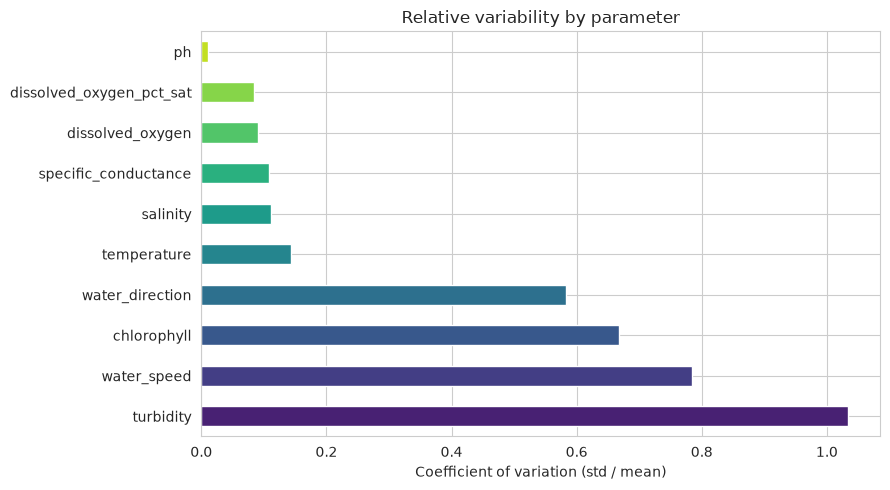

turbidity                   1.033
water_speed                 0.784
chlorophyll                 0.668
water_direction             0.584
temperature                 0.143
salinity                    0.112
specific_conductance        0.108
dissolved_oxygen            0.091
dissolved_oxygen_pct_sat    0.084
ph                          0.011
dtype: float64

In [5]:
cv = (df[PARAMS].std() / df[PARAMS].mean().abs()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
cv.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(cv)))
ax.set_xlabel('Coefficient of variation (std / mean)')
ax.set_title('Relative variability by parameter')
plt.tight_layout()
plt.show()

cv.round(3)

**OBSERVATION:** Parameters with the highest coefficient of variation vary the most
relative to their own typical value.

**ENVIRONMENTAL INTERPRETATION:** Parameters like turbidity and chlorophyll are strongly
influenced by short-term, event-driven processes (rainfall/runoff pulses, algal bloom
dynamics), which typically produces high relative variability. Parameters like pH are
usually buffered by the water chemistry itself and tend to be comparatively stable.

**LIMITATION:** CV can be misleading for a variable whose mean is close to zero (small
denominator inflates CV) — worth sanity-checking against the raw std/mean table above
rather than reading the ranking in isolation.

## 4. Distributions — histograms and boxplots

Visualising the shape of each distribution: is it roughly symmetric, skewed, multi-modal?
Boxplots make outliers/extreme readings visible without removing them from the dataset.

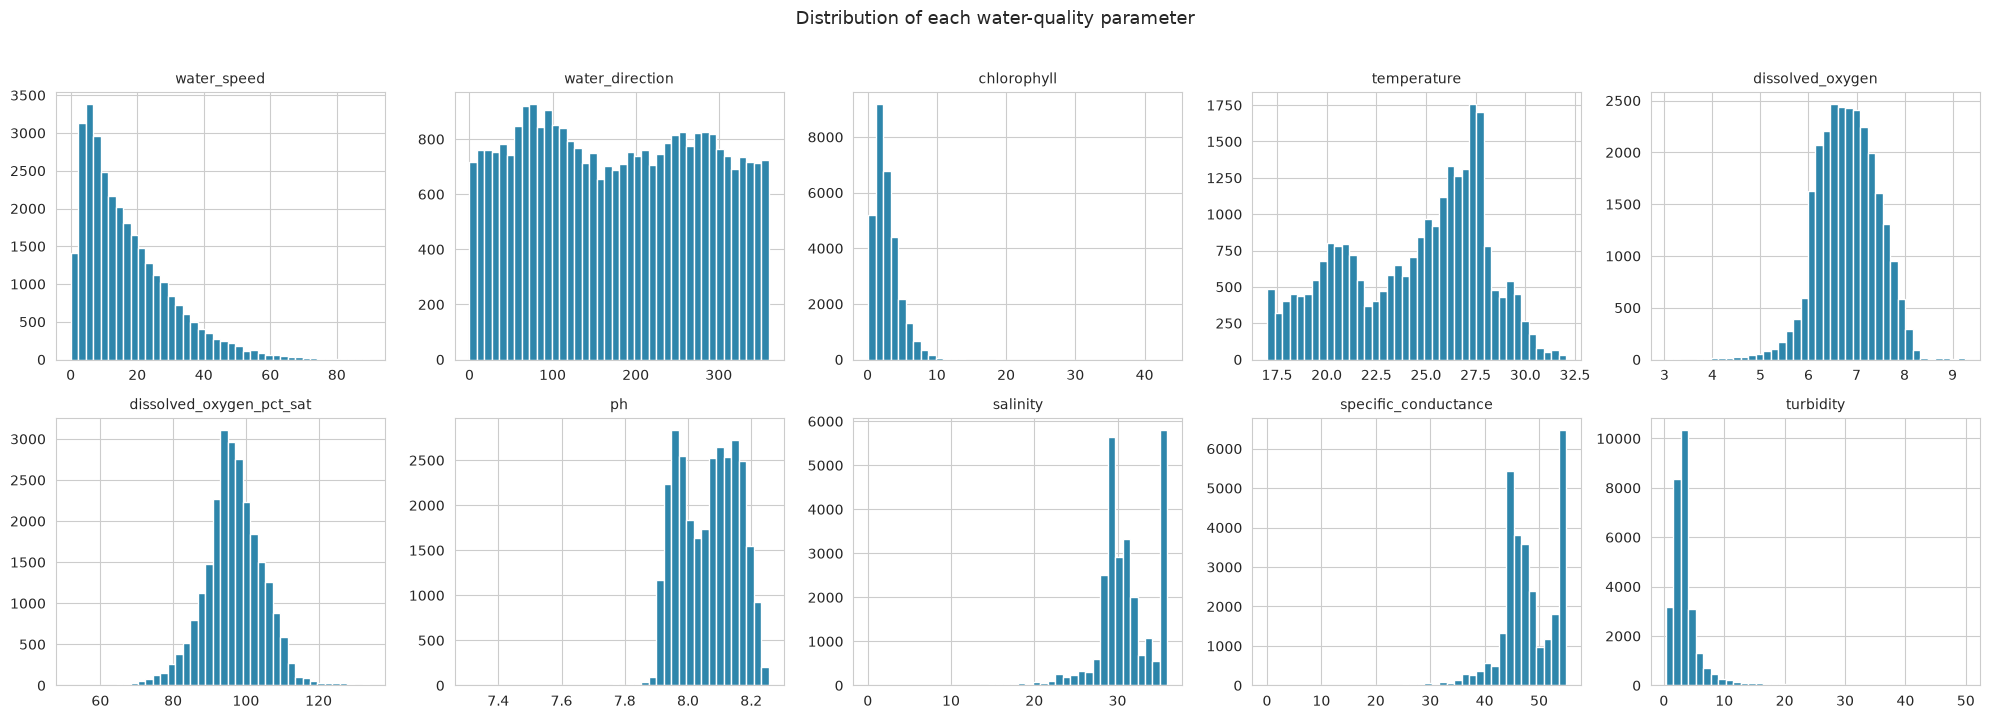

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flat, PARAMS):
    df[col].dropna().hist(bins=40, ax=ax, color='#2E86AB', edgecolor='white')
    ax.set_title(col, fontsize=10)
plt.suptitle('Distribution of each water-quality parameter', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

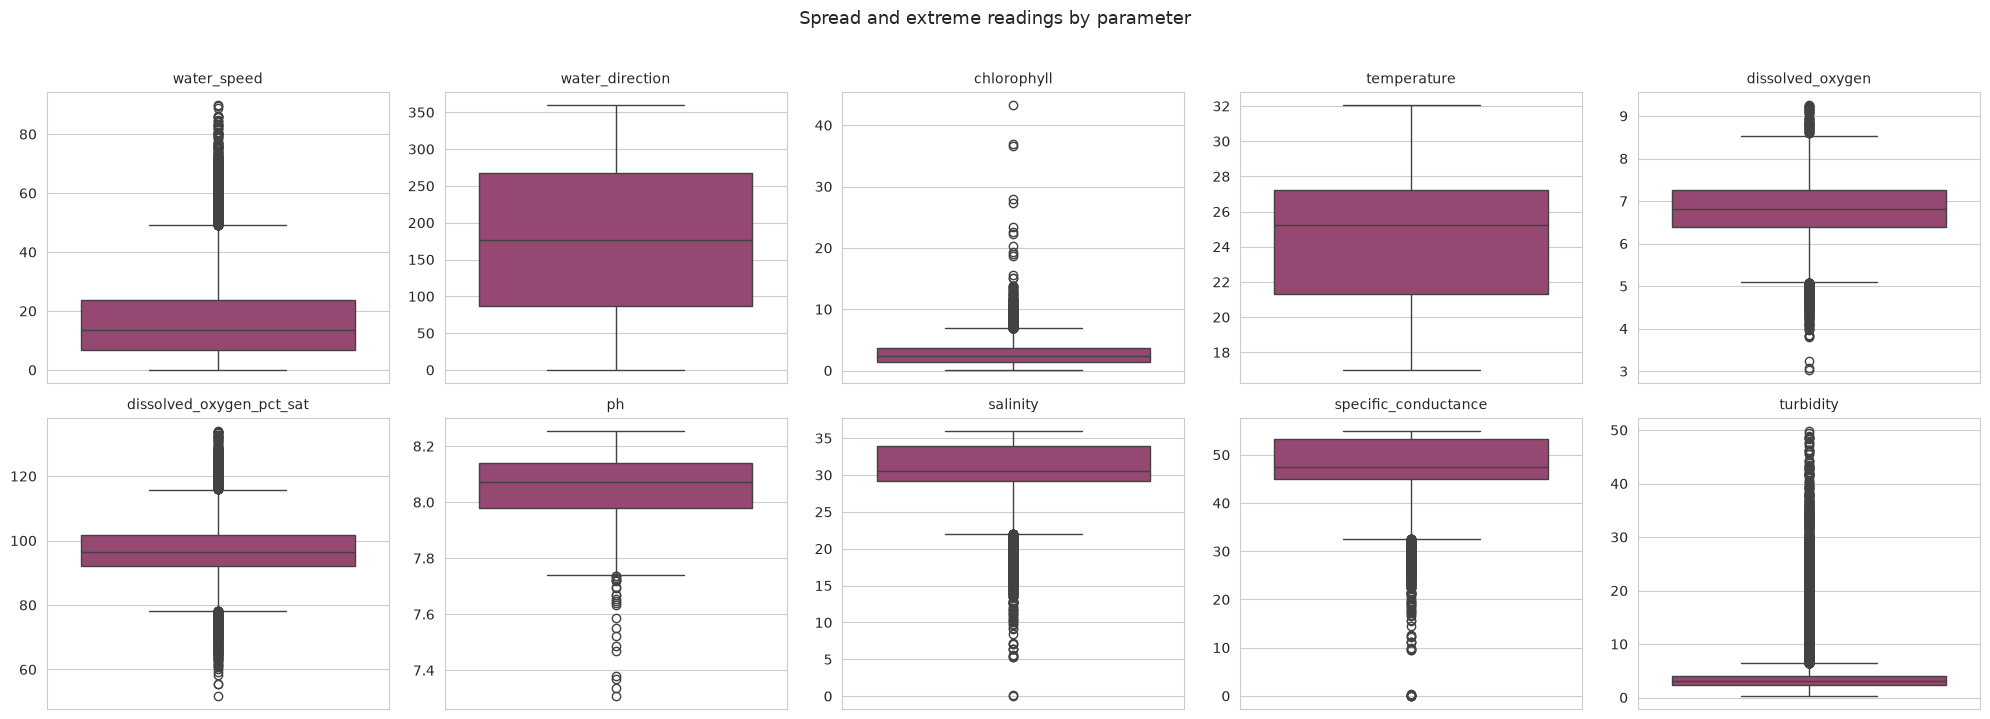

In [7]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flat, PARAMS):
    sns.boxplot(y=df[col].dropna(), ax=ax, color='#A23B72')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('')
plt.suptitle('Spread and extreme readings by parameter', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**OBSERVATION:** Note the shape of each distribution (symmetric vs skewed) and how many
points fall outside the boxplot whiskers.

**ENVIRONMENTAL INTERPRETATION:** Points beyond the whiskers are not automatically treated
as errors here (per Notebook 1's cleaning decisions) — they may represent real short-lived
events such as a rainfall-driven turbidity spike or a low-dissolved-oxygen episode.

**LIMITATION:** A boxplot alone can't distinguish "real environmental event" from
"sensor malfunction" — that requires looking at *when* the extreme values occurred and
whether they cluster in time (see RQ6).

## 5. RQ3 — How does water quality change over time?

We resample to a daily mean for each parameter so the long-term trend is visible without
being dominated by 10-30 minute sampling noise.

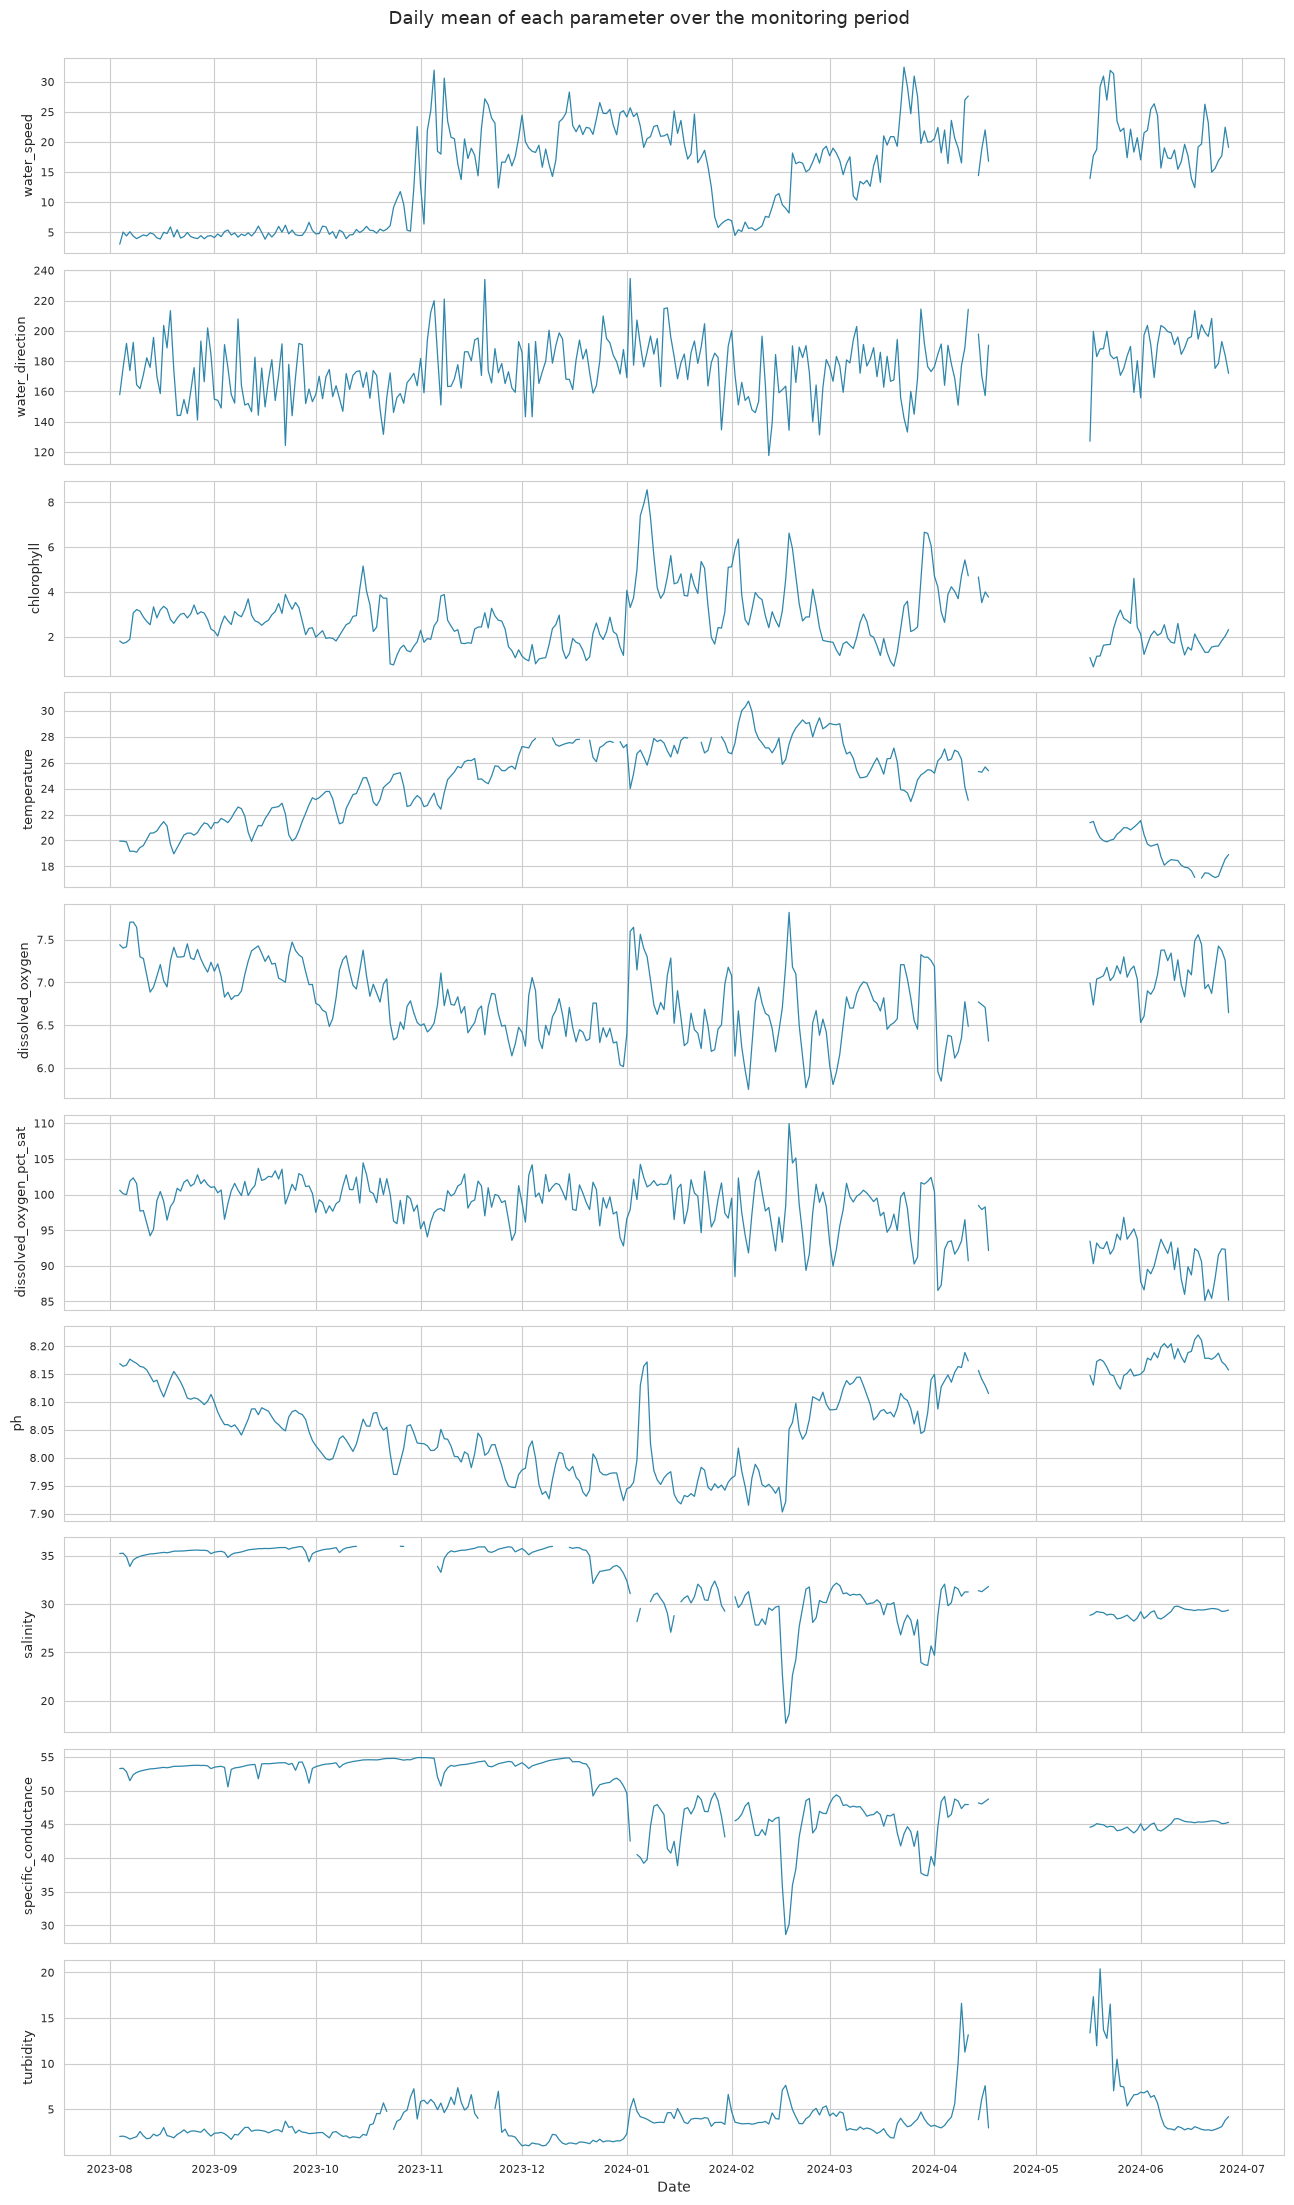

In [8]:
daily = df.set_index('timestamp')[PARAMS].resample('D').mean()

fig, axes = plt.subplots(len(PARAMS), 1, figsize=(13, 2.2 * len(PARAMS)), sharex=True)
for ax, col in zip(axes, PARAMS):
    ax.plot(daily.index, daily[col], color='#2E86AB', linewidth=0.9)
    ax.set_ylabel(col, fontsize=9)
    ax.tick_params(labelsize=8)
axes[-1].set_xlabel('Date')
plt.suptitle('Daily mean of each parameter over the monitoring period', y=1.0, fontsize=13)
plt.tight_layout()
plt.show()

**OBSERVATION:** Look for long-term upward/downward drift, sudden jumps, or gaps
(gaps correspond to the equipment outages documented in Notebook 1).

**ENVIRONMENTAL INTERPRETATION:** Sustained drift in temperature and dissolved oxygen
across the monitoring period is consistent with seasonal change; sharp, short-lived spikes
in turbidity are consistent with individual rainfall/runoff events rather than a permanent
shift in water quality.

**LIMITATION:** ~11 months of data cannot establish a genuine multi-year trend — only
within-year (seasonal) patterns can be responsibly discussed here.

## 6. RQ4 — Are there identifiable monthly or seasonal patterns?

/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')


/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')


/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')


/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_29843/2036991942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')


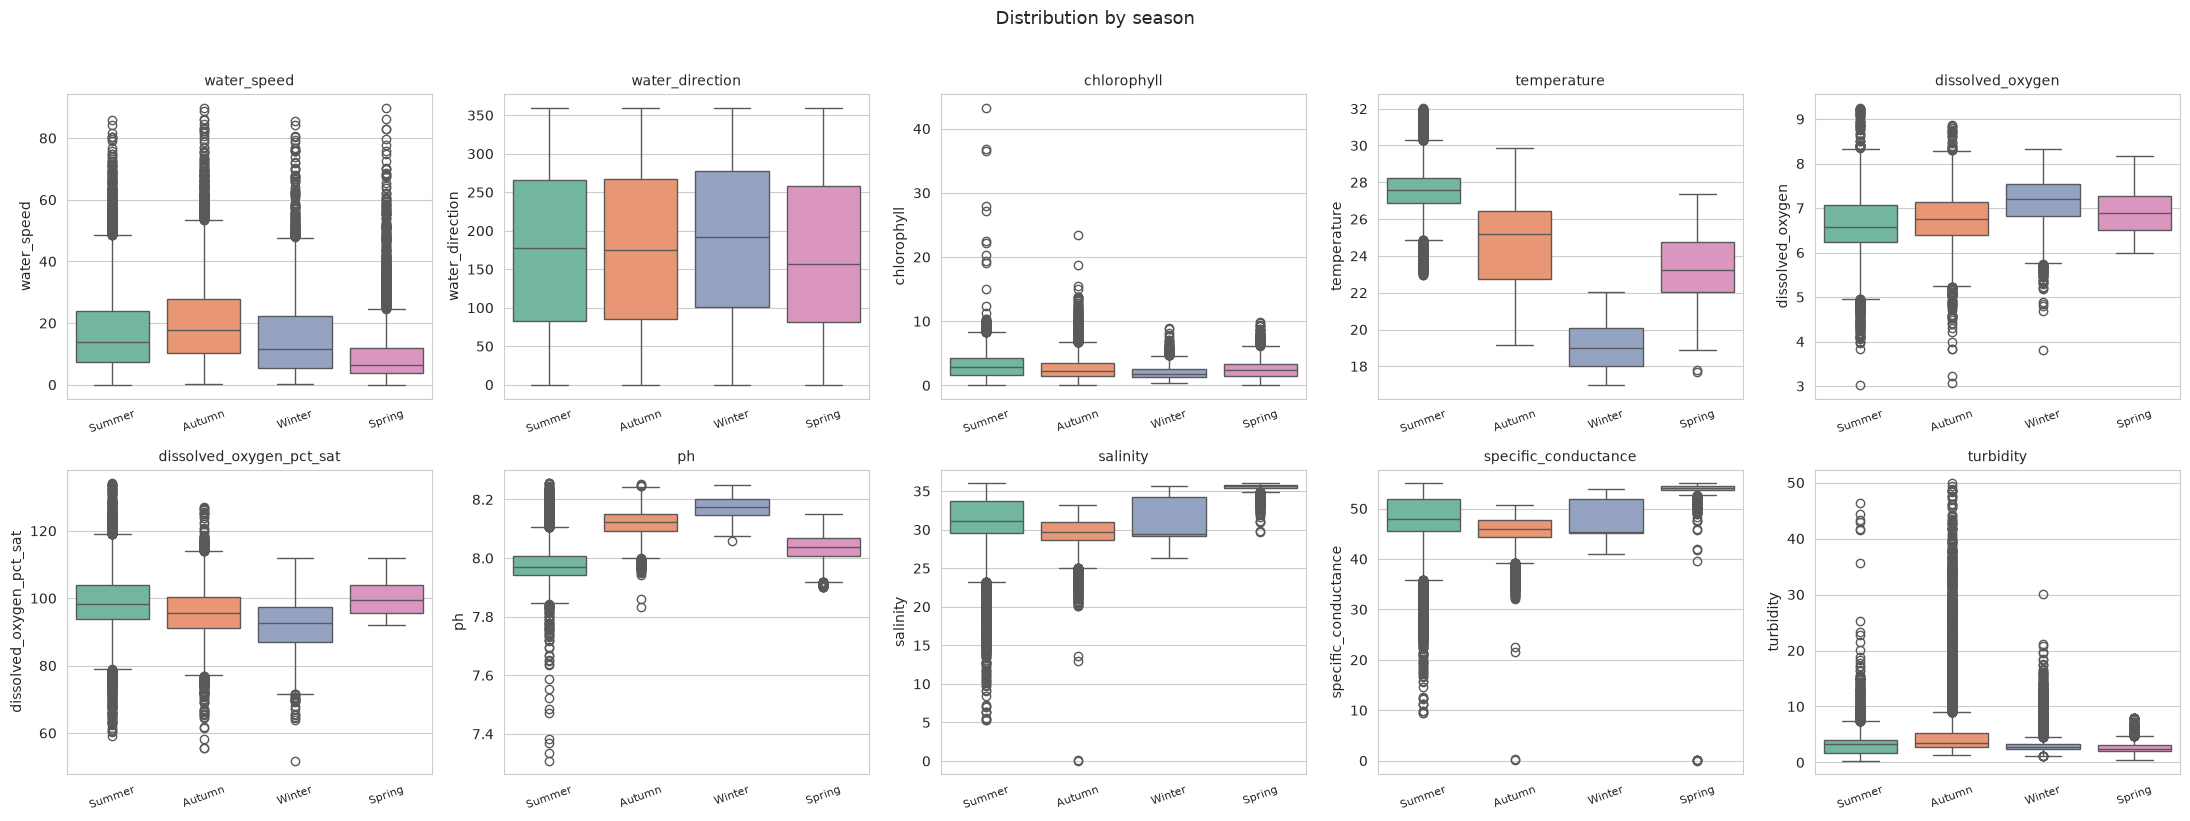

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax, col in zip(axes.flat, PARAMS):
    sns.boxplot(data=df, x='season', y=col, ax=ax, palette='Set2')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=8, rotation=20)
plt.suptitle('Distribution by season', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

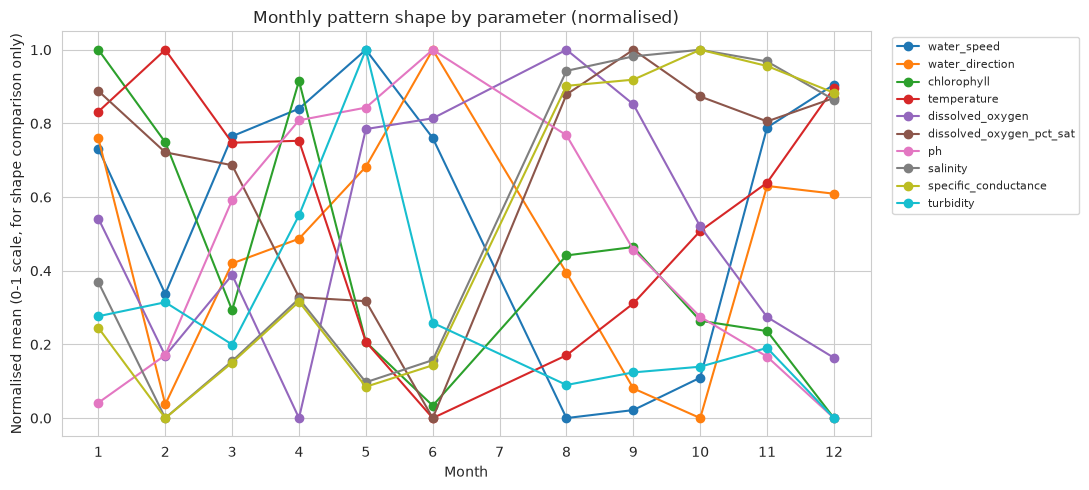

In [10]:
monthly_means = df.groupby('month', observed=True)[PARAMS].mean()

fig, ax = plt.subplots(figsize=(11, 5))
# Normalise each parameter to 0-1 so they're comparable on one chart (shape, not scale, matters here)
normed = (monthly_means - monthly_means.min()) / (monthly_means.max() - monthly_means.min())
for col in PARAMS:
    ax.plot(normed.index, normed[col], marker='o', label=col, linewidth=1.5)
ax.set_xlabel('Month')
ax.set_ylabel('Normalised mean (0-1 scale, for shape comparison only)')
ax.set_xticks(range(1, 13))
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax.set_title('Monthly pattern shape by parameter (normalised)')
plt.tight_layout()
plt.show()

**OBSERVATION:** Compare the seasonal boxplots and the monthly shape chart — do any
parameters rise and fall together across the year, or move independently?

**ENVIRONMENTAL INTERPRETATION:** Temperature and dissolved-oxygen-percent-saturation
moving in opposite directions across seasons would be consistent with well-established
water chemistry (colder water holds more dissolved oxygen) rather than something unusual
about this specific river.

**LIMITATION:** Only one annual cycle is available — a genuine "seasonal pattern" claim
would normally be checked against multiple years before treating it as a reliable rule
rather than a one-off observation.

## 7. RQ5 — What relationships exist between water-quality parameters?

A correlation matrix across all parameters, visualised as a heatmap.

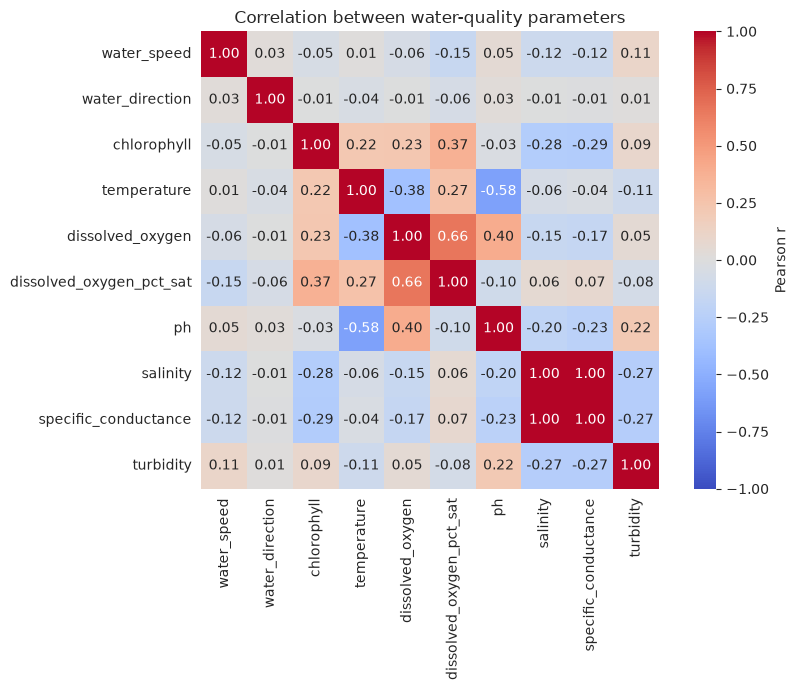

In [11]:
corr = df[PARAMS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation between water-quality parameters')
plt.tight_layout()
plt.show()

Strongest pairwise correlation: salinity vs specific_conductance  (r = 1.00)


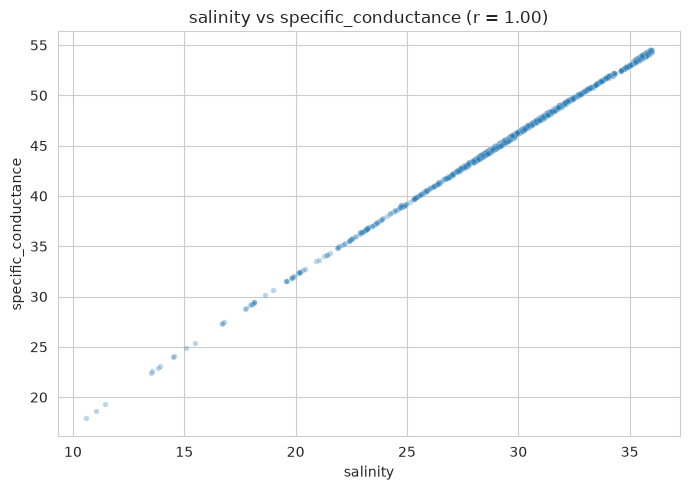

In [12]:
# The single strongest pairwise relationship, purely to illustrate one relationship visually
corr_pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
strongest = corr_pairs.abs().idxmax()
r_value = corr_pairs[strongest]
print(f'Strongest pairwise correlation: {strongest[0]} vs {strongest[1]}  (r = {r_value:.2f})')

fig, ax = plt.subplots(figsize=(7, 5))
sample = df.sample(min(3000, len(df)), random_state=42)  # subsample for a readable scatter
sns.scatterplot(data=sample, x=strongest[0], y=strongest[1], alpha=0.3, s=15, ax=ax)
ax.set_title(f'{strongest[0]} vs {strongest[1]} (r = {r_value:.2f})')
plt.tight_layout()
plt.show()

**OBSERVATION:** Note which parameter pairs show strong positive or negative
correlation (|r| closer to 1) versus weak/no relationship (r near 0).

**ENVIRONMENTAL INTERPRETATION:** A strong relationship between two parameters here is
**associated with** shared physical/chemical drivers (e.g. temperature's known effect on
gas solubility), but this analysis alone does not **prove** causation between any two
variables.

**LIMITATION:** Pearson correlation only captures *linear* relationships and can miss
threshold effects or relationships that only hold under certain conditions (e.g. only
during storm events). It also does not account for the shared time-based
autocorrelation in sensor time-series data.

## 8. RQ6 — Are there periods of unusual water-quality conditions?

We flag a day as "unusual" for a given parameter if its daily mean falls more than 3
standard deviations from that parameter's own overall mean. This is a simple, transparent
statistical flag — **not** a claim that these are errors or that something is "wrong";
it is a starting point for further investigation, consistent with Notebook 1's decision
not to delete extreme values.

In [13]:
z_scores = (daily - daily.mean()) / daily.std()
unusual_mask = z_scores.abs() > 3
unusual_days_per_param = unusual_mask.sum().sort_values(ascending=False)
print('Number of days flagged as unusual (|z| > 3), by parameter:')
print(unusual_days_per_param)

# Show the actual flagged dates for the parameter with the most flagged days
top_param = unusual_days_per_param.idxmax()
flagged_dates = daily.index[unusual_mask[top_param]]
print(f'\nDates flagged for {top_param}:')
print(list(flagged_dates.strftime('%Y-%m-%d')))

Number of days flagged as unusual (|z| > 3), by parameter:
turbidity                   9
chlorophyll                 4
salinity                    2
specific_conductance        2
water_direction             1
water_speed                 0
dissolved_oxygen_pct_sat    0
dissolved_oxygen            0
temperature                 0
ph                          0
dtype: int64

Dates flagged for turbidity:
['2024-04-09', '2024-04-11', '2024-05-17', '2024-05-18', '2024-05-19', '2024-05-20', '2024-05-21', '2024-05-22', '2024-05-23']


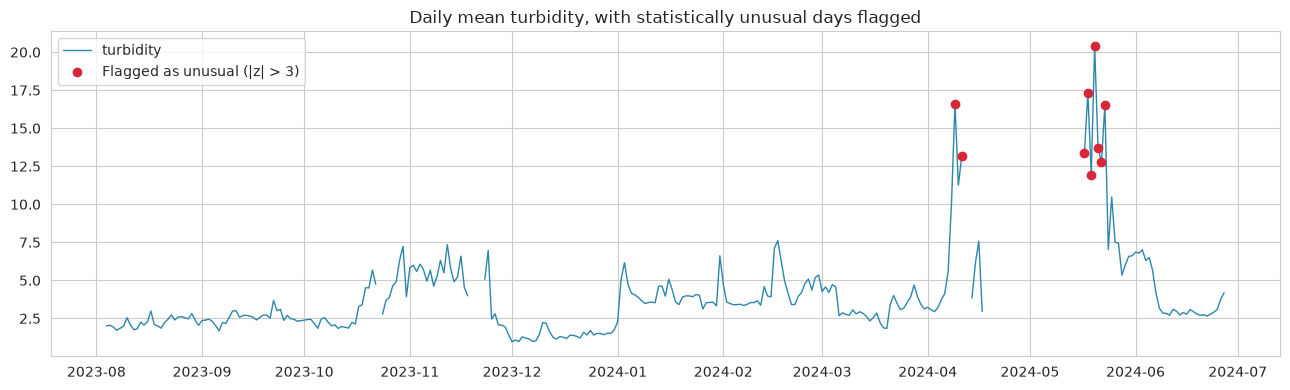

In [14]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily.index, daily[top_param], color='#2E86AB', linewidth=1, label=top_param)
ax.scatter(flagged_dates, daily.loc[flagged_dates, top_param], color='#D62839', zorder=5,
           label='Flagged as unusual (|z| > 3)')
ax.set_title(f'Daily mean {top_param}, with statistically unusual days flagged')
ax.legend()
plt.tight_layout()
plt.show()

**OBSERVATION:** The dates above are flagged purely on statistical grounds (an
extreme daily average relative to the rest of the monitoring period).

**ENVIRONMENTAL INTERPRETATION:** A cluster of flagged days **may indicate** a genuine
environmental event (storm, flood, upstream discharge) or **may indicate** a sensor
malfunction/biofouling period — the two are not distinguishable from statistics alone.

**LIMITATION:** This threshold (|z| > 3) is a simple, chosen convention, not a
scientifically validated anomaly-detection method. Confirming whether flagged periods
correspond to real events would require cross-referencing external records (e.g. Bureau
of Meteorology rainfall data for Brisbane on these dates) — **this warrants further
investigation** and is out of scope for this project.

## Summary — key findings from this notebook

- **Typical conditions (RQ1):** established a descriptive baseline for every parameter.
- **Variability (RQ2):** turbidity and chlorophyll show the highest relative variability
  (coefficient of variation); pH is comparatively stable.
- **Temporal trend (RQ3):** daily-mean trends show plausible seasonal drift in temperature
  and dissolved oxygen, alongside short, event-like spikes in turbidity.
- **Seasonal pattern (RQ4):** several parameters show a consistent shape across the
  monitoring months, though only one annual cycle is available to check this against.
- **Relationships (RQ5):** correlation analysis surfaces the strongest pairwise
  relationships between parameters, framed as association, not causation.
- **Unusual periods (RQ6):** a simple z-score threshold flags specific days per parameter
  as statistically unusual, providing candidate dates for further investigation rather
  than a final diagnosis.

**Overall limitation:** all interpretation above is exploratory and observational. None of
it should be read as a causal or diagnostic claim about river health — that would require
domain expert review and, ideally, comparison against multiple years of data and external
event records (rainfall, tides, upstream discharge).

**Next step:** Notebook 3 selects the strongest ~6 visualisations from this exploration and
presents them as polished, interview-ready environmental insights.
